In [ ]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from google.colab import drive

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
dataset_path = (
    "/content/drive/MyDrive/"
    "TOGG_Driver_Risk_Project/"
    "data/raw/UAH-DRIVESET-v1"
)

print(dataset_path)

/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/raw/UAH-DRIVESET-v1


In [ ]:
drivers = sorted(

    d

    for d in os.listdir(dataset_path)

    if os.path.isdir(
        os.path.join(dataset_path, d)
    )

    and d.startswith("D")

)

drivers

['D1', 'D2', 'D3', 'D4', 'D5', 'D6']

In [ ]:
trip_list = []

for driver in drivers:

    driver_path = os.path.join(
        dataset_path,
        driver
    )

    trips = sorted(

        trip

        for trip in os.listdir(driver_path)

        if os.path.isdir(
            os.path.join(driver_path, trip)
        )

    )

    for trip in trips:

        trip_list.append(

            {

                "driver": driver,

                "trip": trip

            }

        )

len(trip_list)

40

In [ ]:
train_trips, test_trips = train_test_split(

    trip_list,

    test_size=0.20,

    random_state=42

)

print(len(train_trips))

print(len(test_trips))

32
8


In [ ]:
SAMPLING_RATE = 10      # Hz
WINDOW_SECONDS = 3      # seconds

WINDOW_SIZE = SAMPLING_RATE * WINDOW_SECONDS

window_features = [

    "acc_resultant",

    "acc_horizontal",

    "speed",

    "speed_delta",

    "roll",

    "pitch",

    "yaw"

]

In [ ]:
def parse_trip_info(trip_name):

    parts = trip_name.split("-")

    return {
        "date": parts[0],
        "distance": parts[1],
        "driver": parts[2],
        "behavior": parts[3],
        "road_type": parts[4]
    }

In [ ]:
def simplify_behavior(label):

    if "NORMAL" in label:
        return "NORMAL"

    if "AGGRESSIVE" in label:
        return "AGGRESSIVE"

    if "DROWSY" in label:
        return "DROWSY"

    return label

In [ ]:
def process_trip(
    dataset_path,
    driver,
    trip
):

    trip_path = os.path.join(
        dataset_path,
        driver,
        trip
    )

    acc_path = os.path.join(
        trip_path,
        "RAW_ACCELEROMETERS.txt"
    )

    gps_path = os.path.join(
        trip_path,
        "RAW_GPS.txt"
    )

    # Load Sensors
    acc_df = load_accelerometer(acc_path)
    gps_df = load_gps(gps_path)

    # Synchronize
    master_df = synchronize_sensors(
        acc_df,
        gps_df
    )

    # Feature Engineering
    feature_df = engineer_features(master_df)

    # Sliding Window
    window_dataset = create_sliding_windows(
        feature_df,
        window_features,
        WINDOW_SIZE
    )

    # Labels
    info = parse_trip_info(trip)

    window_dataset["driver"] = info["driver"]
    window_dataset["road_type"] = info["road_type"]
    window_dataset["behavior"] = simplify_behavior(
        info["behavior"]
    )

    return window_dataset

In [ ]:
train_datasets = []

for trip in train_trips:

    print(
        f"Processing Train: "
        f"{trip['driver']} - {trip['trip']}"
    )

    trip_dataset = process_trip(

        dataset_path,

        trip["driver"],

        trip["trip"]

    )

    train_datasets.append(
        trip_dataset
    )

Processing Train: D6 - 20151221120051-26km-D6-AGGRESSIVE-MOTORWAY
Processing Train: D1 - 20151111135612-13km-D1-DROWSY-SECONDARY
Processing Train: D4 - 20151204152848-25km-D4-NORMAL-MOTORWAY
Processing Train: D2 - 20151120135152-25km-D2-DROWSY-MOTORWAY
Processing Train: D2 - 20151120164606-16km-D2-DROWSY-SECONDARY
Processing Train: D5 - 20151211162829-16km-D5-NORMAL1-SECONDARY
Processing Train: D5 - 20151211170502-16km-D5-DROWSY-SECONDARY
Processing Train: D2 - 20151120133502-26km-D2-AGGRESSIVE-MOTORWAY
Processing Train: D3 - 20151126125458-16km-D3-NORMAL2-SECONDARY
Processing Train: D4 - 20151203175637-17km-D4-DROWSY-SECONDARY
Processing Train: D1 - 20151110175712-16km-D1-NORMAL1-SECONDARY
Processing Train: D5 - 20151211165606-12km-D5-AGGRESSIVE-SECONDARY
Processing Train: D1 - 20151111134545-16km-D1-AGGRESSIVE-SECONDARY
Processing Train: D2 - 20151120162105-17km-D2-NORMAL2-SECONDARY
Processing Train: D1 - 20151110180824-16km-D1-NORMAL2-SECONDARY
Processing Train: D5 - 20151209153137-

In [23]:
train_dataset = pd.concat(
    train_datasets,
    ignore_index=True
)

train_dataset.shape

(243925, 45)

In [24]:
train_dataset.head()

,acc_resultant_mean,acc_resultant_std,acc_resultant_min,acc_resultant_max,acc_resultant_median,acc_resultant_rms,acc_horizontal_mean,acc_horizontal_std,acc_horizontal_min,acc_horizontal_max,...,pitch_rms,yaw_mean,yaw_std,yaw_min,yaw_max,yaw_median,yaw_rms,driver,road_type,behavior
0,0.058162,0.040807,0.014213,0.178804,0.047605,0.070658,0.051064,0.037351,0.001414,0.140004,...,0.010596,-0.033400,0.002472,-0.037,-0.029,-0.0335,0.033488,D6,MOTORWAY,AGGRESSIVE
1,0.054311,0.033896,0.014213,0.141287,0.047605,0.063721,0.048567,0.034008,0.001414,0.140004,...,0.011027,-0.033333,0.002591,-0.037,-0.028,-0.0335,0.033431,D6,MOTORWAY,AGGRESSIVE
2,0.055394,0.033481,0.014213,0.141287,0.050094,0.064437,0.049765,0.033695,0.001414,0.140004,...,0.011435,-0.033133,0.002909,-0.037,-0.026,-0.0335,0.033257,D6,MOTORWAY,AGGRESSIVE
3,0.053637,0.033202,0.014213,0.141287,0.047605,0.062790,0.050241,0.033256,0.001414,0.140004,...,0.011435,-0.032833,0.003354,-0.037,-0.024,-0.0335,0.032998,D6,MOTORWAY,AGGRESSIVE
4,0.051045,0.031886,0.014213,0.141287,0.044649,0.059903,0.047618,0.031777,0.001414,0.140004,...,0.011364,-0.032400,0.003865,-0.037,-0.022,-0.0325,0.032622,D6,MOTORWAY,AGGRESSIVE


In [25]:
train_dataset["behavior"].value_counts()

,count
behavior,
NORMAL,116653
AGGRESSIVE,64031
DROWSY,63241


In [26]:
test_datasets = []

for trip in test_trips:

    print(
        f"Processing Test: "
        f"{trip['driver']} - {trip['trip']}"
    )

    trip_dataset = process_trip(
        dataset_path,
        trip["driver"],
        trip["trip"]
    )

    test_datasets.append(
        trip_dataset
    )

Processing Test: D3 - 20151126132013-17km-D3-DROWSY-SECONDARY
Processing Test: D3 - 20151126124208-16km-D3-NORMAL1-SECONDARY
Processing Test: D3 - 20151126113754-26km-D3-DROWSY-MOTORWAY
Processing Test: D4 - 20151204154908-25km-D4-AGGRESSIVE-MOTORWAY
Processing Test: D1 - 20151111132348-25km-D1-DROWSY-MOTORWAY
Processing Test: D2 - 20151120163350-16km-D2-AGGRESSIVE-SECONDARY
Processing Test: D6 - 20151221112434-17km-D6-NORMAL-SECONDARY
Processing Test: D4 - 20151204160823-25km-D4-DROWSY-MOTORWAY


In [27]:
test_dataset = pd.concat(
    test_datasets,
    ignore_index=True
)

test_dataset.shape

(66300, 45)

In [28]:
target_column = "behavior"

feature_columns = [
    col for col in train_dataset.columns
    if col not in [
        "behavior",
        "driver",
        "road_type"
    ]
]

X_train = train_dataset[feature_columns]
y_train = train_dataset[target_column]

X_test = test_dataset[feature_columns]
y_test = test_dataset[target_column]

print(X_train.shape)
print(X_test.shape)

(243925, 42)
(66300, 42)


In [29]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(243925, 42)
(66300, 42)


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train_encoded
)

print("Model trained successfully!")

Model trained successfully!


In [32]:
y_pred = rf_model.predict(X_test)

y_pred[:10]

array([0, 0, 2, 2, 2, 2, 2, 2, 2, 2])

In [33]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test_encoded,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.4565


In [34]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.63      0.57      0.60     15317
      DROWSY       0.69      0.31      0.43     36263
      NORMAL       0.28      0.69      0.40     14720

    accuracy                           0.46     66300
   macro avg       0.54      0.52      0.48     66300
weighted avg       0.59      0.46      0.46     66300



<Figure size 700x700 with 0 Axes>

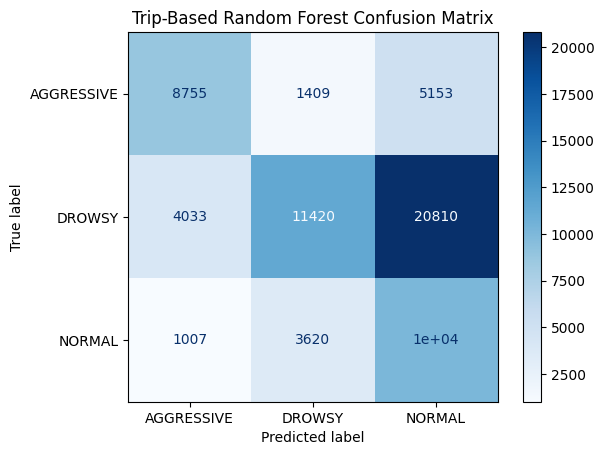

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(7,7))
disp.plot(cmap="Blues")

plt.title("Trip-Based Random Forest Confusion Matrix")

plt.show()

In [36]:
train_dataset.to_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/train_dataset.csv",
    index=False
)

test_dataset.to_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/test_dataset.csv",
    index=False
)

print("Datasets saved successfully.")

Datasets saved successfully.
